In [1]:
import pandas as pd

df = pd.read_csv("../data/heart.csv")
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [2]:
X = df.drop('target', axis=1)
y = df['target']

In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [17]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, classification_report

In [19]:
print("LR Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

LR Accuracy: 0.7951219512195122
              precision    recall  f1-score   support

           0       0.83      0.75      0.78       102
           1       0.77      0.84      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



In [20]:
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

RF Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [21]:
print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGB Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [22]:
results = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred)
}

results

{'Logistic Regression': 0.7951219512195122,
 'Random Forest': 0.9853658536585366,
 'XGBoost': 0.9853658536585366}

In [23]:
best_model = max(results, key=results.get)
print("Best Model:", best_model)

Best Model: Random Forest


In [24]:
print("Train accuracy:", rf.score(X_train, y_train))
print("Test accuracy:", rf.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy: 0.9853658536585366


In [27]:
df.shape

(1025, 14)

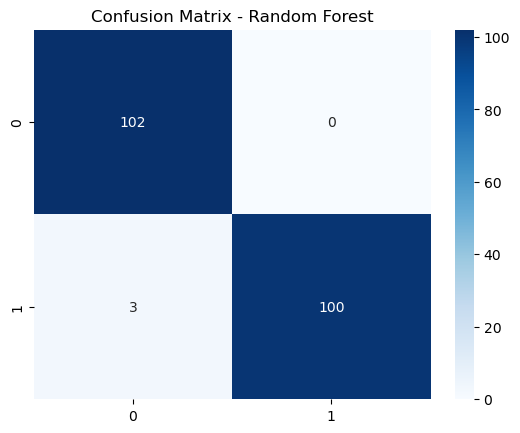

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

pred = rf.predict(X_test)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



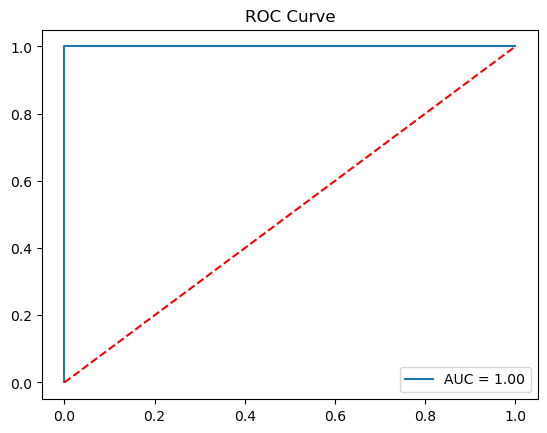

In [30]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.title("ROC Curve")
plt.legend()
plt.show()

In [31]:
import pandas as pd

importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feat_imp

,Feature,Importance
2,chest_pain_type,0.132266
12,thalassemia,0.132048
11,vessels_colored_by_flourosopy,0.122825
9,oldpeak,0.122702
7,Max_heart_rate,0.120991
0,age,0.077909
4,cholestoral,0.077015
3,resting_blood_pressure,0.069030
8,exercise_induced_angina,0.049155
10,slope,0.043238


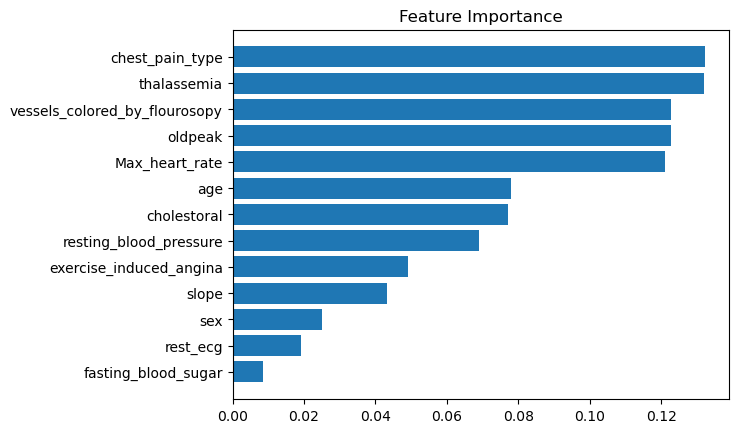

In [32]:
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [33]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel

In [34]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

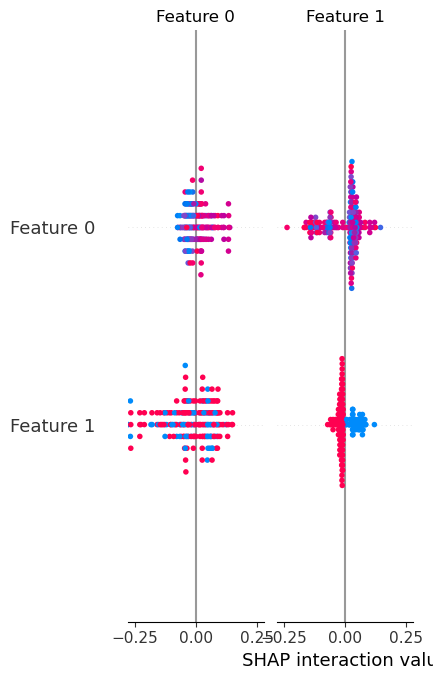

In [35]:
shap.summary_plot(shap_values, X_test)

In [37]:
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_test[0])

DimensionError: Length of features is not equal to the length of shap_values!

In [38]:
import pandas as pd

X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [39]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_df)

In [41]:
type(shap_values)

numpy.ndarray

In [42]:
print(len(shap_values))

205


In [44]:
shap.initjs()

In [45]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_df.iloc[0]
)

TypeError: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

In [40]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[1][0],
    X_test_df.iloc[0]
)

DimensionError: Length of features is not equal to the length of shap_values!

In [46]:
y_prob = rf.predict_proba(X_test)[:,1]

In [47]:
def risk_level(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

risk_predictions = [risk_level(p) for p in y_prob]
risk_predictions[:10]

['High Risk',
 'High Risk',
 'Low Risk',
 'High Risk',
 'Low Risk',
 'High Risk',
 'Low Risk',
 'Low Risk',
 'High Risk',
 'Low Risk']

In [48]:
def explain_risk(prob):
    if prob > 0.7:
        return "Immediate medical attention recommended"
    elif prob > 0.3:
        return "Monitor health regularly"
    else:
        return "Healthy condition"

In [49]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_prob,
    "Risk Level": risk_predictions
})

results.head()

,Actual,Probability,Risk Level
0,1,1.00,High Risk
1,1,0.91,High Risk
2,0,0.00,Low Risk
3,1,1.00,High Risk
4,0,0.01,Low Risk


In [53]:
import os

os.makedirs("models", exist_ok=True)

In [54]:
import joblib

joblib.dump(rf, "models/model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

In [55]:
import os

print(os.listdir("models"))

['model.pkl', 'scaler.pkl']
